In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import os

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import pandas as pd
import numpy as np
df = pd.read_csv("../Processed_data/unified_data_new.csv")
# ---- Reuse the same setup as your main models (same-architecture, augur_hu) ----
hu = df[df["source_dataset"] == "augur_hu"].copy()
hu["task_type"] = hu["process"].str.split(":").str[-1].str.upper()
hu_enc = pd.get_dummies(hu, columns=["task_type"], prefix="task")

base_features = ["rchar", "cpus", "concurrent_task_count"]
task_features = [c for c in hu_enc.columns if c.startswith("task_")]
feature_cols = base_features + task_features

def compare_baselines(data, target):
    """Compare RF vs Linear vs Mean-predictor on the SAME split for one target."""
    d = data.dropna(subset=[target] + base_features)
    d = d[d[target] > 0]
    X, y = d[feature_cols], d[target]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

    models = {
        "Mean predictor":  DummyRegressor(strategy="mean"),
        "Linear (simple)": LinearRegression(),
        "Random Forest":   RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    }
    rows = []
    for name, model in models.items():
        model.fit(Xtr, ytr)
        pred = model.predict(Xte)
        rows.append({
            "target": target,
            "method": name,
            "r2": r2_score(yte, pred),
            "mape": mean_absolute_percentage_error(yte, pred),
        })
    return rows

# Run for all three targets
all_rows = []
for target in ["runtime_s", "peak_mem", "energy_j"]:
    all_rows.extend(compare_baselines(hu_enc, target))

baseline_df = pd.DataFrame(all_rows)

# Pretty per-target tables
for target in ["runtime_s", "peak_mem", "energy_j"]:
    print(f"\n=== {target} ===")
    sub = baseline_df[baseline_df["target"] == target][["method", "r2", "mape"]]
    print(sub.to_string(index=False))

baseline_df.to_csv("baseline_comparison.csv", index=False)


=== runtime_s ===
         method        r2      mape
 Mean predictor -0.001262 73.232894
Linear (simple)  0.256125 59.498954
  Random Forest  0.991560  0.131018

=== peak_mem ===
         method        r2       mape
 Mean predictor -0.000063 217.670548
Linear (simple)  0.022531 203.717118
  Random Forest  0.984259   0.125586

=== energy_j ===
         method        r2      mape
 Mean predictor -0.000007 13.559582
Linear (simple)  0.252700 10.890300
  Random Forest  0.950389  0.174208


In [3]:
baseline_df.to_csv("../Processed_data/baseline_comparison.csv", index=False)

# Feature Importance

In [ ]:
hu = df[df["source_dataset"] == "augur_hu"].copy()
hu["task_type"] = hu["process"].str.split(":").str[-1].str.upper()
hu_enc = pd.get_dummies(hu,columns=["task_type"], prefix="task")

base_features = ["rchar","cpus","concurrent_task_count"]
task_features = [c for c in hu_enc.columns if c.startswith("task_")]
feature_cols = base_features + task_features

['rchar',
 'cpus',
 'concurrent_task_count',
 'task_ANNOTATE_BOOLEAN_PEAKS',
 'task_BAMBU',
 'task_BAMTOOLS_FILTER',
 'task_BAM_FILTER',
 'task_BAM_REMOVE_ORPHANS',
 'task_BEDTOOLS_BAMBED',
 'task_BEDTOOLS_GENOMECOV',
 'task_BWA_MEM',
 'task_CUSTOM_DUMPSOFTWAREVERSIONS',
 'task_CUSTOM_GETCHROMSIZES',
 'task_DEEPTOOLS_COMPUTEMATRIX',
 'task_DEEPTOOLS_COMPUTEMATRIX_REFERENCE_POINT',
 'task_DEEPTOOLS_COMPUTEMATRIX_SCALE_REGIONS',
 'task_DEEPTOOLS_PLOTFINGERPRINT',
 'task_DEEPTOOLS_PLOTHEATMAP',
 'task_DEEPTOOLS_PLOTPROFILE',
 'task_DESEQ2',
 'task_DESEQ2_QC',
 'task_DESEQ2_QC_SALMON',
 'task_DESEQ2_QC_STAR_SALMON',
 'task_DEXSEQ',
 'task_DUPRADAR',
 'task_FASTQC',
 'task_FRIP_SCORE',
 'task_GENOME_BLACKLIST_REGIONS',
 'task_GET_AUTOSOMES',
 'task_GET_CHROM_SIZES',
 'task_GTF2BED',
 'task_GTF_GENE_FILTER',
 'task_HOMER_ANNOTATEPEAKS',
 'task_HOMER_ANNOTATEPEAKS_CONSENSUS',
 'task_HOMER_ANNOTATEPEAKS_MACS2',
 'task_IGV',
 'task_MACS2_CALLPEAK',
 'task_MACS2_CONSENSUS',
 'task_MAKE_TRANSCRIP

In [12]:
def feature_importance(data,target):
    d= data.dropna(subset=[target] + base_features)
    d = d[d[target] > 0]
    X,y = d[feature_cols], d[target]
    X_train,_,y_train,_= train_test_split(X,y,test_size=0.2,random_state=42)
    model = RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)
    model.fit(X_train,y_train)

    imp = pd.Series(model.feature_importances_,index=feature_cols)

    collapsed = {
        "task_type (all)": imp[task_features].sum(),
        "rchar (input size)": imp["rchar"],
        "cpus": imp["cpus"],
        "concurrent_task_count": imp["concurrent_task_count"],
    }

    return pd.Series(collapsed).sort_values(ascending=False)

results = {t: feature_importance(hu_enc,t) for t in ["runtime_s","peak_mem","energy_j"]}

for target,imp in results.items():
    print(f"\n=== {target} ===")
    for name, val in imp.items():
        print(f"  {name:25s} {val:.3f}")




=== runtime_s ===
  rchar (input size)        0.516
  task_type (all)           0.465
  concurrent_task_count     0.012
  cpus                      0.007

=== peak_mem ===
  task_type (all)           0.868
  rchar (input size)        0.129
  concurrent_task_count     0.003
  cpus                      0.000

=== energy_j ===
  rchar (input size)        0.567
  task_type (all)           0.414
  concurrent_task_count     0.014
  cpus                      0.006


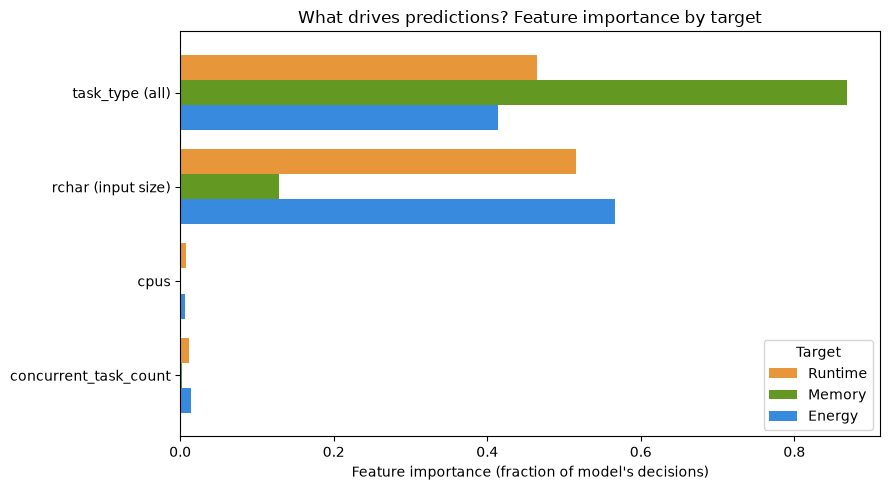

In [13]:
# ---- Plot: grouped bar chart, one group per feature, bars per target ----
imp_df = pd.DataFrame(results)  # rows=features, cols=targets
imp_df = imp_df.loc[["task_type (all)", "rchar (input size)", "cpus", "concurrent_task_count"]]

ax = imp_df.plot(kind="barh", figsize=(9, 5), width=0.8,
                 color={"runtime_s": "#E8963A", "peak_mem": "#639922", "energy_j": "#378ADD"})
ax.set_xlabel("Feature importance (fraction of model's decisions)")
ax.set_title("What drives predictions? Feature importance by target")
ax.legend(title="Target", labels=["Runtime", "Memory", "Energy"])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


=== runtime_s (cross-architecture) ===
  task_type (all)           0.463
  rchar (input size)        0.454
  hardware (all)            0.063
  concurrent_task_count     0.014
  cpus                      0.006

=== peak_mem (cross-architecture) ===
  task_type (all)           0.876
  rchar (input size)        0.119
  concurrent_task_count     0.004
  hardware (all)            0.001
  cpus                      0.001

=== energy_j (cross-architecture) ===
  rchar (input size)        0.535
  task_type (all)           0.438
  hardware (all)            0.013
  concurrent_task_count     0.008
  cpus                      0.006


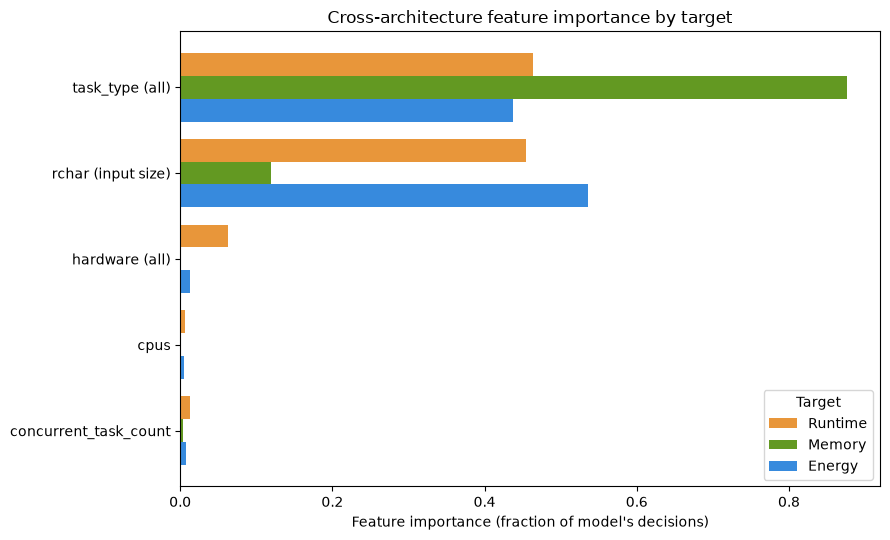

In [14]:

# ---- Both Augur clusters, so hardware features VARY ----
aug = df[df["source_dataset"].isin(["augur_gu", "augur_hu"])].copy()
aug["task_type"] = aug["process"].str.split(":").str[-1].str.upper()
aug_enc = pd.get_dummies(aug, columns=["task_type"], prefix="task")

# Now hardware features are meaningful (they differ between gu and hu)
hw_features = ["cores", "ram", "cpu_benchmark", "io_read", "io_write"]
base_features = ["rchar", "cpus", "concurrent_task_count"] + hw_features
task_features = [c for c in aug_enc.columns if c.startswith("task_")]
feature_cols = base_features + task_features

def feature_importance_xarch(data, target):
    d = data.dropna(subset=[target] + base_features)
    d = d[d[target] > 0]
    X, y = d[feature_cols], d[target]
    Xtr, _, ytr, _ = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    model.fit(Xtr, ytr)

    imp = pd.Series(model.feature_importances_, index=feature_cols)
    collapsed = {
        "task_type (all)":      imp[task_features].sum(),
        "rchar (input size)":   imp["rchar"],
        "hardware (all)":       imp[hw_features].sum(),   # combined hardware importance
        "cpus":                 imp["cpus"],
        "concurrent_task_count": imp["concurrent_task_count"],
    }
    return pd.Series(collapsed).sort_values(ascending=False)

results_x = {t: feature_importance_xarch(aug_enc, t) for t in ["runtime_s", "peak_mem", "energy_j"]}

for target, imp in results_x.items():
    print(f"\n=== {target} (cross-architecture) ===")
    for name, val in imp.items():
        print(f"  {name:25s} {val:.3f}")

# Plot
imp_df = pd.DataFrame(results_x).loc[
    ["task_type (all)", "rchar (input size)", "hardware (all)", "cpus", "concurrent_task_count"]
]
ax = imp_df.plot(kind="barh", figsize=(9, 5.5), width=0.8,
                 color={"runtime_s": "#E8963A", "peak_mem": "#639922", "energy_j": "#378ADD"})
ax.set_xlabel("Feature importance (fraction of model's decisions)")
ax.set_title("Cross-architecture feature importance by target")
ax.legend(title="Target", labels=["Runtime", "Memory", "Energy"])
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance_xarch.png", dpi=150, bbox_inches="tight")
plt.show()